In [1]:
###신용카드 이상감지 모델을 만들기 위함.
##1. 사기거래 여부를 예측하는 데 불필요한 컬럼을 제거합니다.
##2. 최소 2개 이상의 새로// 운 피처(변수)를 생성해봅시다. [힌트] 구매 금액, 시간 등의 변수를 이용할 수 있습니다.
##3. 데이터의 위도/경도 정보를 활용해볼 수 있을까요? (인터넷 검색 적극 활용)
##4. 통계적 관점으로 접근하여 유용한 변수를 만들어낼 수 있을까요?

In [ ]:
# 사기를 놓치는 것에 대한 실제 금전적 손실 발생에 중점을 둘 것인가?
# 정상을 사기로 판단하는 고객 불편과 신뢰 손실을 중점으로 둘 것인가?
# 기본 지식을 토대로 판단했을때는 사기를 놓치는것에 대한 금전적 손실발생에 중점을 두는게 맞지 않나? 생각중.

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic' #matplotlib가 사용하는 기본폰트가 한글을 지원안하기에 사용
plt.rcParams['axes.unicode_minus'] = False #음수부호가 깨지는 문제 방지하는 코드

pd.set_option('display.max_columns', None) #실습에서는 None 자리에 숫자를 넣음. None은 컬럼수 제한 해제.
sns.set_theme(style='whitegrid') #표의 테마를 지정하는 코드 "darkgrid""whitegrid""white""ticks""dark" 다양하게 존재.

In [4]:
df = pd.read_csv('fraud.csv')

In [5]:
df = df.rename(columns={
    'trans_date_trans_time': '거래일시',
    'trans_num': '거래ID',
    'amt': '거래금액',
    'unix_time': '유닉스타임스탬프',
    
    'cc_num': '카드번호',
    'first': '이름',
    'last': '성',
    'gender': '성별',
    'dob': '생년월일',
    'job': '직업',
    
    'street': '주소',
    'city': '도시',
    'state': '주',
    'zip': '우편번호',
    'lat': '위도',
    'long': '경도',
    'city_pop': '도시인구',
    
    'merchant': '가맹점명',
    'category': '결제_단말기',
    'merch_lat': '가맹점_위도',
    'merch_long': '가맹점_경도',
    
    'is_fraud': '사기여부'
})

In [6]:
print(df.shape)
df.head()

(491134, 22)


,거래일시,카드번호,가맹점명,결제_단말기,거래금액,이름,성,성별,주소,도시,주,우편번호,위도,경도,도시인구,직업,생년월일,거래ID,유닉스타임스탬프,가맹점_위도,가맹점_경도,사기여부
0,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
1,2019-01-01 00:12:34,4956828990005111019,"fraud_Schultz, Simonis and Little",grocery_pos,44.71,Kenneth,Robinson,M,269 Sanchez Rapids,Elizabeth,NJ,7208,40.6747,-74.2239,124967,Operational researcher,1980-12-21,09eff9c806365e2a6be12c1bbab3d70e,1325376754,40.079588,-74.848087,0
2,2019-01-01 00:17:16,180048185037117,fraud_Kling-Grant,grocery_net,46.28,Mary,Wall,F,2481 Mills Lock,Plainfield,NJ,7060,40.6152,-74.4150,71485,Leisure centre manager,1974-07-19,19e23c6a300c774354417befe4f31f8c,1325377036,40.021888,-74.228188,0
3,2019-01-01 00:20:15,374930071163758,fraud_Deckow-O'Conner,grocery_pos,64.09,Daniel,Escobar,M,61390 Hayes Port,Romulus,MI,48174,42.2203,-83.3583,31515,Police officer,1971-11-05,6f363661ba6b55889e488dd178f2a0af,1325377215,42.360426,-83.552316,0
4,2019-01-01 00:23:41,2712209726293386,fraud_Balistreri-Nader,misc_pos,25.58,Jenna,Brooks,F,50872 Alex Plain Suite 088,Baton Rouge,LA,70808,30.4066,-91.1468,378909,"Designer, furniture",1977-02-22,1654da2abfb9e79a5f99167fc9779558,1325377421,29.737426,-90.853194,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 491134 entries, 0 to 491133
Data columns (total 22 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   거래일시      491134 non-null  object 
 1   카드번호      491134 non-null  int64  
 2   가맹점명      491134 non-null  object 
 3   결제_단말기    491134 non-null  object 
 4   거래금액      491134 non-null  float64
 5   이름        491134 non-null  object 
 6   성         491134 non-null  object 
 7   성별        491134 non-null  object 
 8   주소        491134 non-null  object 
 9   도시        491134 non-null  object 
 10  주         491134 non-null  object 
 11  우편번호      491134 non-null  int64  
 12  위도        491134 non-null  float64
 13  경도        491134 non-null  float64
 14  도시인구      491134 non-null  int64  
 15  직업        491134 non-null  object 
 16  생년월일      491134 non-null  object 
 17  거래ID      491134 non-null  object 
 18  유닉스타임스탬프  491134 non-null  int64  
 19  가맹점_위도    491134 non-null  float64
 20  가맹점_

In [8]:
df.describe()

,카드번호,거래금액,우편번호,위도,경도,도시인구,유닉스타임스탬프,가맹점_위도,가맹점_경도,사기여부
count,4.911340e+05,491134.000000,491134.000000,491134.000000,491134.000000,4.911340e+05,4.911340e+05,491134.000000,491134.000000,491134.000000
mean,3.706013e+17,69.050120,50770.532384,37.931230,-90.495619,1.213922e+05,1.358730e+09,37.930272,-90.495411,0.002533
std,1.260229e+18,160.322867,26854.947965,5.341193,12.990732,3.725751e+05,1.819402e+07,5.372986,13.004100,0.050264
min,5.038744e+11,1.000000,1843.000000,24.655700,-122.345600,4.600000e+01,1.325376e+09,23.655789,-123.345106,0.000000
25%,2.131124e+14,8.960000,28405.000000,33.746700,-97.235100,1.228000e+03,1.343087e+09,33.781388,-96.984814,0.000000
50%,3.531130e+15,42.170000,49628.000000,38.507200,-87.591700,5.760000e+03,1.357257e+09,38.545124,-87.573441,0.000000
75%,4.653879e+15,80.330000,75048.000000,41.520500,-80.731000,5.083500e+04,1.374626e+09,41.624294,-80.685567,0.000000
max,4.956829e+18,25086.940000,99323.000000,48.887800,-69.965600,2.906700e+06,1.388534e+09,49.887523,-68.965624,1.000000


In [9]:
#head, info, describe 확인
#1. 카드번호, 가맹점명, 이름, 성, 주소, 우편번호, 거래ID, 유닉스타임스탬프처럼 랜덤부여되는 정보나 개인정보는 삭제. 
#   도시, 주는 사기비율과 연관지어 설명할 수 있을 수 있으므로 보류
#2. 결측치는 없고, Datetime 형식으로 변환이 필요한 변수는 거래일시, 생년월일이고 생년월일은 사기당시 나이로 변환.
#3. 사기 발생률이 0.002533 으로 사기비율이 매우 낮음. 그렇기때문에, 막대나 산점도 그래프는 의미가 없다고 판단됨.
#4. 거래금액은 달러로 되어있으므로 한화로 변환한 변수를 추가 생성.

df = df.drop(columns =  ['카드번호', '가맹점명', '이름', '성', '주소', '우편번호', '거래ID', '유닉스타임스탬프'])

df.head() #삭제확인

,거래일시,결제_단말기,거래금액,성별,도시,주,위도,경도,도시인구,직업,생년월일,가맹점_위도,가맹점_경도,사기여부
0,2019-01-01 00:00:44,grocery_pos,107.23,F,Orient,WA,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,49.159047,-118.186462,0
1,2019-01-01 00:12:34,grocery_pos,44.71,M,Elizabeth,NJ,40.6747,-74.2239,124967,Operational researcher,1980-12-21,40.079588,-74.848087,0
2,2019-01-01 00:17:16,grocery_net,46.28,F,Plainfield,NJ,40.6152,-74.4150,71485,Leisure centre manager,1974-07-19,40.021888,-74.228188,0
3,2019-01-01 00:20:15,grocery_pos,64.09,M,Romulus,MI,42.2203,-83.3583,31515,Police officer,1971-11-05,42.360426,-83.552316,0
4,2019-01-01 00:23:41,misc_pos,25.58,F,Baton Rouge,LA,30.4066,-91.1468,378909,"Designer, furniture",1977-02-22,29.737426,-90.853194,0


In [10]:
#Datetime 형식으로 생년월일과 거래일시를 변환함
df['거래일시'] = pd.to_datetime(df['거래일시'])
df['생년월일'] = pd.to_datetime(df['생년월일'])

#거래당시 나이 속성 추가 및 생년월일 삭제.
df['나이'] = (df['거래일시'] - df['생년월일']).dt.days // 365
df = df.drop(columns = ['생년월일'])

df.head() #삭제확인

,거래일시,결제_단말기,거래금액,성별,도시,주,위도,경도,도시인구,직업,가맹점_위도,가맹점_경도,사기여부,나이
0,2019-01-01 00:00:44,grocery_pos,107.23,F,Orient,WA,48.8878,-118.2105,149,Special educational needs teacher,49.159047,-118.186462,0,40
1,2019-01-01 00:12:34,grocery_pos,44.71,M,Elizabeth,NJ,40.6747,-74.2239,124967,Operational researcher,40.079588,-74.848087,0,38
2,2019-01-01 00:17:16,grocery_net,46.28,F,Plainfield,NJ,40.6152,-74.4150,71485,Leisure centre manager,40.021888,-74.228188,0,44
3,2019-01-01 00:20:15,grocery_pos,64.09,M,Romulus,MI,42.2203,-83.3583,31515,Police officer,42.360426,-83.552316,0,47
4,2019-01-01 00:23:41,misc_pos,25.58,F,Baton Rouge,LA,30.4066,-91.1468,378909,"Designer, furniture",29.737426,-90.853194,0,41


In [11]:
#거래일시를 확인해보니 2019-01-01 부터 2020-12-31 까지 2년치 데이터임
#순서대로 되어있는듯 보이지만 다시 정렬해서 확인처리해보는것이 좋다고 판단
df.head(10)
df.tail(10)
df = df.sort_values('거래일시') 
df

,거래일시,결제_단말기,거래금액,성별,도시,주,위도,경도,도시인구,직업,가맹점_위도,가맹점_경도,사기여부,나이
0,2019-01-01 00:00:44,grocery_pos,107.23,F,Orient,WA,48.8878,-118.2105,149,Special educational needs teacher,49.159047,-118.186462,0,40
1,2019-01-01 00:12:34,grocery_pos,44.71,M,Elizabeth,NJ,40.6747,-74.2239,124967,Operational researcher,40.079588,-74.848087,0,38
2,2019-01-01 00:17:16,grocery_net,46.28,F,Plainfield,NJ,40.6152,-74.4150,71485,Leisure centre manager,40.021888,-74.228188,0,44
3,2019-01-01 00:20:15,grocery_pos,64.09,M,Romulus,MI,42.2203,-83.3583,31515,Police officer,42.360426,-83.552316,0,47
4,2019-01-01 00:23:41,misc_pos,25.58,F,Baton Rouge,LA,30.4066,-91.1468,378909,"Designer, furniture",29.737426,-90.853194,0,41
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
491129,2020-12-31 23:56:48,home,134.26,F,Wilmington,NC,34.2651,-77.8670,186140,English as a second language teacher,34.853497,-78.664158,0,37
491130,2020-12-31 23:56:57,shopping_pos,25.49,F,Bradley,SC,34.0326,-82.2027,1523,Research scientist (physical sciences),35.008839,-81.475156,0,36
491131,2020-12-31 23:59:09,kids_pets,111.84,M,Lake Jackson,TX,29.0393,-95.4401,28739,Futures trader,29.661049,-96.186633,0,21
491132,2020-12-31 23:59:15,kids_pets,86.88,F,Burbank,WA,46.1966,-118.9017,3684,Musician,46.658340,-119.715054,0,39


In [12]:
rate = 1200  # 2019년~2020년의 환율, 1달러 = 1200원으로 대략 계산.

df['거래금액(한화)'] = df['거래금액'] * rate

df.head() #거래금액(한화) 확인

,거래일시,결제_단말기,거래금액,성별,도시,주,위도,경도,도시인구,직업,가맹점_위도,가맹점_경도,사기여부,나이,거래금액(한화)
0,2019-01-01 00:00:44,grocery_pos,107.23,F,Orient,WA,48.8878,-118.2105,149,Special educational needs teacher,49.159047,-118.186462,0,40,128676.0
1,2019-01-01 00:12:34,grocery_pos,44.71,M,Elizabeth,NJ,40.6747,-74.2239,124967,Operational researcher,40.079588,-74.848087,0,38,53652.0
2,2019-01-01 00:17:16,grocery_net,46.28,F,Plainfield,NJ,40.6152,-74.4150,71485,Leisure centre manager,40.021888,-74.228188,0,44,55536.0
3,2019-01-01 00:20:15,grocery_pos,64.09,M,Romulus,MI,42.2203,-83.3583,31515,Police officer,42.360426,-83.552316,0,47,76908.0
4,2019-01-01 00:23:41,misc_pos,25.58,F,Baton Rouge,LA,30.4066,-91.1468,378909,"Designer, furniture",29.737426,-90.853194,0,41,30696.0


In [13]:
# 하버사인 공식을 활용해 위도/경도 정보를 이용해 고객과 가맹점의 거리를 계산.
# 위도/경도는 도 단위이므로 라디안 단위로 변환 필요. drg2red = 라디안

def to_rad(x):
    return np.deg2rad(x)

R = 6371  # 지구 반지름 (km)

lat1 = to_rad(df['위도'])
lon1 = to_rad(df['경도'])
lat2 = to_rad(df['가맹점_위도'])
lon2 = to_rad(df['가맹점_경도'])

dlat = lat2 - lat1
dlon = lon2 - lon1

a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
c = 2 * np.arcsin(np.sqrt(a))

df['고객_가맹점_거리_km'] = R * c

df = df.drop(columns=['위도', '경도', '가맹점_위도', '가맹점_경도'])

df.head()

,거래일시,결제_단말기,거래금액,성별,도시,주,도시인구,직업,사기여부,나이,거래금액(한화),고객_가맹점_거리_km
0,2019-01-01 00:00:44,grocery_pos,107.23,F,Orient,WA,149,Special educational needs teacher,0,40,128676.0,30.212176
1,2019-01-01 00:12:34,grocery_pos,44.71,M,Elizabeth,NJ,124967,Operational researcher,0,38,53652.0,84.702120
2,2019-01-01 00:17:16,grocery_net,46.28,F,Plainfield,NJ,71485,Leisure centre manager,0,44,55536.0,67.847742
3,2019-01-01 00:20:15,grocery_pos,64.09,M,Romulus,MI,31515,Police officer,0,47,76908.0,22.303906
4,2019-01-01 00:23:41,misc_pos,25.58,F,Baton Rouge,LA,378909,"Designer, furniture",0,41,30696.0,79.591943


In [14]:
#주말여부 및 심야시간 컬럼을 0과 1로 생성.

df['거래_연'] = df['거래일시'].dt.year
df['거래_월'] = df['거래일시'].dt.month
df['거래_일'] = df['거래일시'].dt.day
df['거래_요일'] = df['거래일시'].dt.weekday
df['거래_시'] = df['거래일시'].dt.hour

df['주말여부'] = df['거래_요일'].isin([5,6]).astype(int) #dt.weekday에서 0~6(월~일).
df['심야거래'] = df['거래_시'].between(0,5).astype(int) #between(a,b)는 a이상 b이하 심야시간.

df.head()

,거래일시,결제_단말기,거래금액,성별,도시,주,도시인구,직업,사기여부,나이,거래금액(한화),고객_가맹점_거리_km,거래_연,거래_월,거래_일,거래_요일,거래_시,주말여부,심야거래
0,2019-01-01 00:00:44,grocery_pos,107.23,F,Orient,WA,149,Special educational needs teacher,0,40,128676.0,30.212176,2019,1,1,1,0,0,1
1,2019-01-01 00:12:34,grocery_pos,44.71,M,Elizabeth,NJ,124967,Operational researcher,0,38,53652.0,84.702120,2019,1,1,1,0,0,1
2,2019-01-01 00:17:16,grocery_net,46.28,F,Plainfield,NJ,71485,Leisure centre manager,0,44,55536.0,67.847742,2019,1,1,1,0,0,1
3,2019-01-01 00:20:15,grocery_pos,64.09,M,Romulus,MI,31515,Police officer,0,47,76908.0,22.303906,2019,1,1,1,0,0,1
4,2019-01-01 00:23:41,misc_pos,25.58,F,Baton Rouge,LA,378909,"Designer, furniture",0,41,30696.0,79.591943,2019,1,1,1,0,0,1


In [29]:
df = df.rename(columns={
    '거래일시': 'transaction_datetime',
    '결제_단말기': 'device_type',
    '거래금액': 'amount',
    '성별': 'gender',
    '도시': 'city',
    '주': 'state',
    '도시인구': 'city_population',
    '직업': 'job',
    '사기여부': 'fraud_flag',
    '나이': 'age',
    '거래금액(한화)': 'amount_krw',
    '고객_가맹점_거리_km': 'distance_km',
    
    '거래_연': 'year',
    '거래_월': 'month',
    '거래_일': 'day',
    '거래_요일': 'weekday',
    '거래_시': 'hour',

    '주말여부': 'is_weekend',
    '심야거래': 'is_night'
})

df.head()

,transaction_datetime,device_type,amount,gender,city,state,city_population,job,fraud_flag,age,amount_krw,distance_km,year,month,day,weekday,hour,is_weekend,is_night,log_amount
0,2019-01-01 00:00:44,grocery_pos,107.23,F,Orient,WA,149,Special educational needs teacher,0,40,128676.0,30.212176,2019,1,1,1,0,0,1,4.684259
1,2019-01-01 00:12:34,grocery_pos,44.71,M,Elizabeth,NJ,124967,Operational researcher,0,38,53652.0,84.702120,2019,1,1,1,0,0,1,3.822317
2,2019-01-01 00:17:16,grocery_net,46.28,F,Plainfield,NJ,71485,Leisure centre manager,0,44,55536.0,67.847742,2019,1,1,1,0,0,1,3.856087
3,2019-01-01 00:20:15,grocery_pos,64.09,M,Romulus,MI,31515,Police officer,0,47,76908.0,22.303906,2019,1,1,1,0,0,1,4.175771
4,2019-01-01 00:23:41,misc_pos,25.58,F,Baton Rouge,LA,378909,"Designer, furniture",0,41,30696.0,79.591943,2019,1,1,1,0,0,1,3.280159


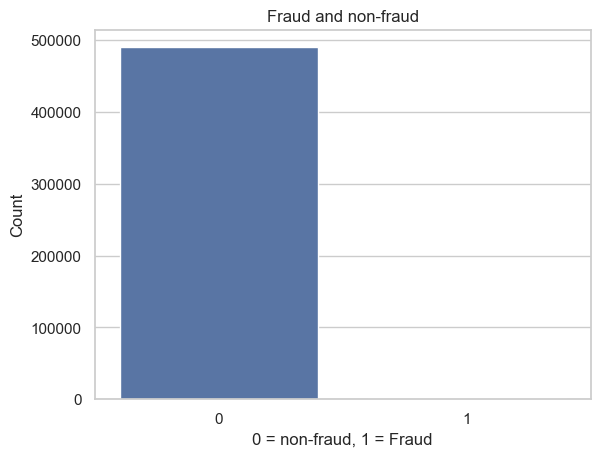

0.0025329136243876418

In [ ]:
#타겟 불균형이 얼마나 심한지를 그래프로 표현.
#시각화 과정중, 한글폰트 인식이 안되는 문제가 발생 추후 작업시, 미리 고려해야함. 그래서 선행으로 다시 영어로 변경함.

sns.countplot(x='fraud_flag', data=df)
plt.xlabel('0 = non-fraud, 1 = Fraud')
plt.ylabel('Count')
plt.show()

fraud_rate = df['fraud_flag'].mean()
fraud_rate

#사기여부 비율차이가 매우 큼.

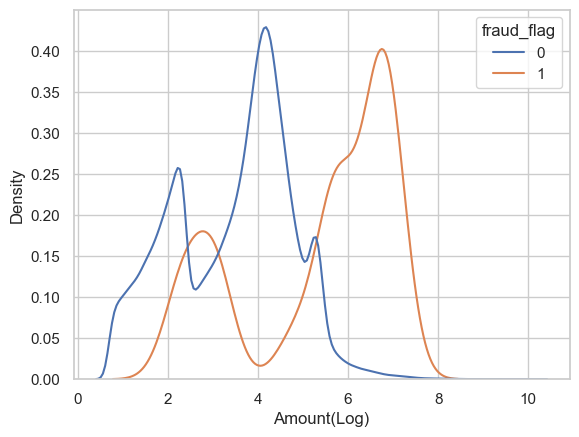

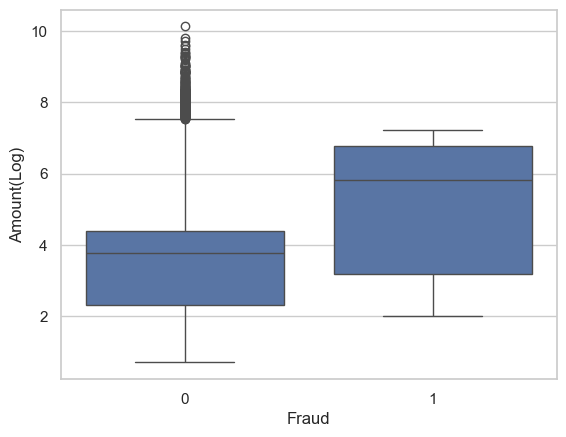

In [ ]:
#거래금액을 로그로 변환하여 사기여부와 분포를 판단해봄.

df['log_amount'] = np.log1p(df['amount']) #np.log1p(x) = log(1+x)

# KDE plot
sns.kdeplot(data=df, x='log_amount', hue='fraud_flag', common_norm=False)
plt.xlabel('Amount(Log)')
plt.ylabel('Density')
plt.show()

# Boxplot
sns.boxplot(data=df, x='fraud_flag', y='log_amount')
plt.xlabel('Fraud')
plt.ylabel('Amount(Log)')
plt.show()

#소액사기도 존재하나, 금액이 클수록 사기발생 비율이 높아짐.

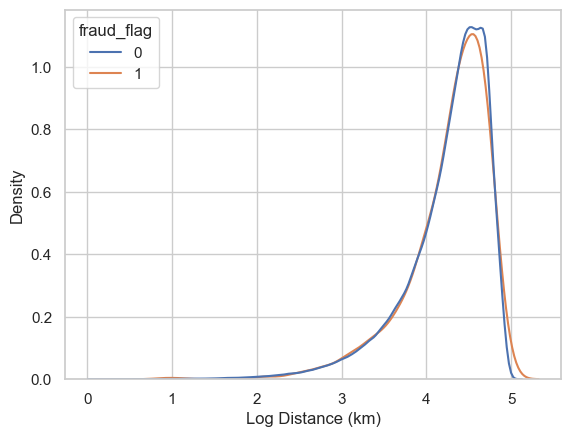

In [ ]:
#거리를 로그로 변환하여 사기여부와 비교해봄.

df['log_distance'] = np.log1p(df['distance_km'])

sns.kdeplot(data=df, x='log_distance', hue='fraud_flag', common_norm=False) #common_norm 은 True가 기본값 
plt.xlabel('Log Distance (km)')
plt.ylabel('Density')
plt.show()

#non_fraud 와 fraud가 일치하므로 거리와 사기여부관계는 의미없음.

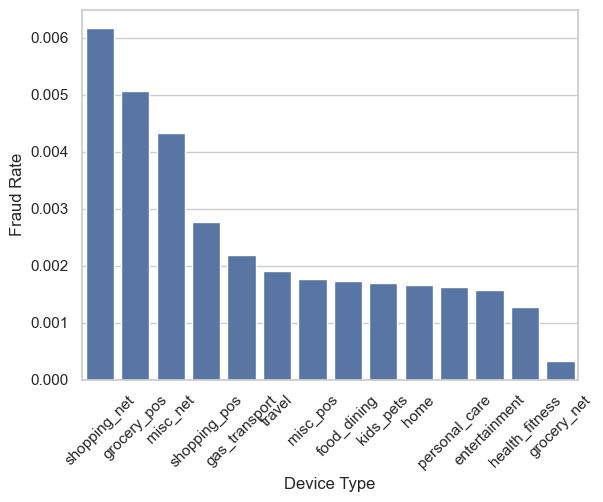

In [50]:
#groupby를 사용하여 단말기와 사기여부 비교.

fraud_rate = (
    df.groupby('device_type')['fraud_flag']
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

sns.barplot(data=fraud_rate, x='device_type', y='fraud_flag')
plt.xlabel('Device Type')
plt.ylabel('Fraud Rate')
plt.xticks(rotation=45) #x축의 단어가 가로로 되면 읽기가 힘드므로 45%기울여서 표기하라는 의미.
plt.show()

#shopping_net, grocery_pos, misc_net, shopping_pos의 비율이 높음. 정확히 어떤결제구조인지 파악이 어렵지만
#실제 서비스 운영에 있어서 보안정책이 약하거나 허술할것으로 예측됨. 보안정책 강화등이 필요.

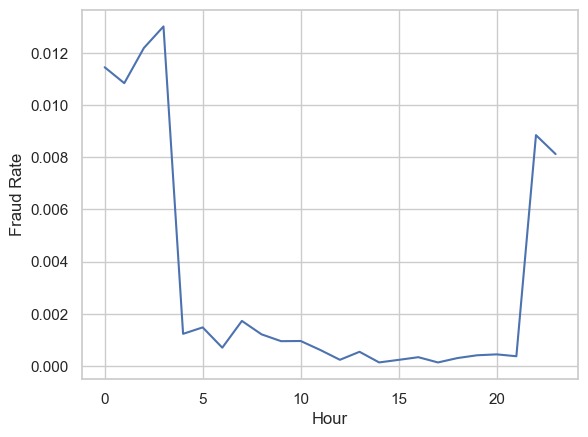

In [ ]:
#거래시간에 따른 사기여부를 확인함.

fraud_by_hour = df.groupby('hour')['fraud_flag'].mean()

plt.plot(fraud_by_hour.index, fraud_by_hour.values)
plt.xlabel('Hour')
plt.ylabel('Fraud Rate')
plt.grid(True) #눈금선 표시 시각적 옵션
plt.show()

#심야시간 or 20시 이후 사기 비율이 높음.

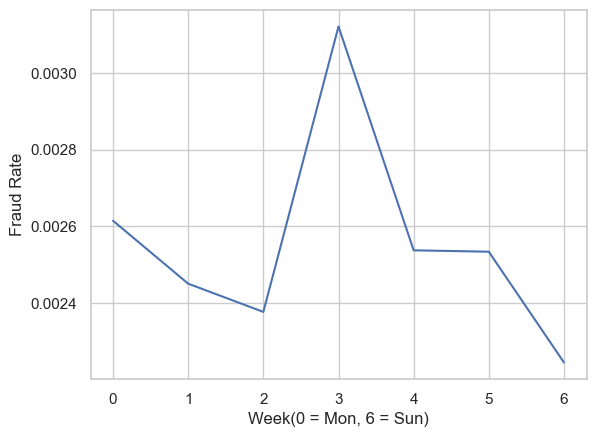

In [ ]:
#거래요일에 따른 사기여부를 확인함.

fraud_by_weekday = df.groupby('weekday')['fraud_flag'].mean()

plt.plot(fraud_by_weekday.index, fraud_by_weekday.values)
plt.xlabel('Week(0 = Mon, 6 = Sun)')
plt.ylabel('Fraud Rate')
plt.grid(True)
plt.show()

#목요일(3)에 특히 사기비율이 높음. 해당 나라의 특정 이벤트가 발생하는 요일일 수 있음.

In [ ]:
##표 해석 결과.
#1. 사기여부 비율차이가 매우 큼.
#2. 소액사기도 존재하나, 금액이 클수록 사기발생 비율이 높아짐.
#3. non_fraud 와 fraud가 일치하므로 거리와 사기여부관계는 의미없음.
#4. shopping_net, grocery_pos, misc_net, shopping_pos의 비율이 높음. 정확히 어떤결제구조인지 파악이 어렵지만
#   실제 서비스 운영에 있어서 보안정책이 약하거나 허술할것으로 예측됨. 보안정책 강화등이 필요.
#5. 심야시간 or 20시 이후 사기 비율이 높음.
#6. 목요일(3)에 특히 사기비율이 높음. 해당 나라의 특정 이벤트가 발생하는 요일일 수 있음.

#큰 금액의 사기발생비율이 어느 시간 어느 요일에 많이 발생하는지 체크.
#큰 금액의 사기발생은 거리가 먼곳에서 일어나는지 적게 일어나는지 봐야함.
#결제 단말기가 정확히 어떤의미인지 파악불가하며 높은 비율을 차지하는것중 큰 금액사기는 어떤 단말기에서 이뤄지는지 파악해봐야함.
#큰 금액 사기발생이 오전때는 이뤄지지 않는지 볼 필요 있음.
#큰 금액의 사기발생의 요일에 대해서 볼 필요 있음.(금,토,일 부근에도 있지 않을까 생각).

#3가지 속성(컬럼)을 다뤄서 분석해봐야하는데, 감이 안잡힘 그룹바이써야할것같은데 다시공부;;